**Linear Regression: Your First Predictive Model**

The concept is straightforward: show the model enough labeled examples — apartments where we already know both the size and the sale price — and it will learn the mathematical relationship between them. Once it has learned that relationship, give it a new apartment's size and it will estimate the price.

This lesson focuses on one feature (surface_covered_in_m2) rather than all available features. This is intentional. Starting with a single variable lets us visualize exactly what the model is doing  

Starting simple, verifying it works, then adding complexity is the disciplined approach to machine learning.

In [1]:
# Importing necessary libraries:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from glob import glob

In [2]:
# Mounting the drive:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
def merged_files(data):
  return pd.concat([pd.read_csv(file) for file in data], ignore_index=True)

def filter_df(data):
  return(
    data
    .loc[lambda x: x["place_with_parent_names"].str.contains("Capital Federal")]
    .query('property_type == "apartment"')
    .query('price_aprox_usd < 400_000')
  )

def outliers_df(data):
  return (
      data
      .loc[lambda x: x['surface_covered_in_m2'].between(
          x['surface_covered_in_m2'].quantile(0.1),
          x['surface_covered_in_m2'].quantile(0.9),
      )]
  )

def modify_cols(data):
  return(
      data
      .assign(
          lat=lambda x: x['lat-lon'].str.split(",", expand=True)[0].astype(float),
          lon=lambda x: x['lat-lon'].str.split(",", expand=True)[1].astype(float),
          neighbourhood=lambda x: x['place_with_parent_names'].str.split("|", expand=True)[3]
      )
  )

def clean_files(file_path):
  drop_cols = [
     "lat-lon", "place_with_parent_names",
    "floor", "expenses", "rooms", "price",
    "price_aprox_local_currency", "price_usd_per_m2",
    "price_per_m2", "operation", "property_type", "currency",
    "properati_url", "surface_total_in_m2"
  ]

  return (
     merged_files(file_path)
     .pipe(filter_df)
     .pipe(outliers_df)
     .pipe(modify_cols)
     .drop(columns=drop_cols)
     .dropna()
     )

In [4]:
df = clean_files(glob("/content/drive/MyDrive/buenos-aires-real-estate-*.csv"))
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6247 entries, 4 to 43026
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        6247 non-null   float64
 1   surface_covered_in_m2  6247 non-null   float64
 2   lat                    6247 non-null   float64
 3   lon                    6247 non-null   float64
 4   neighbourhood          6247 non-null   object 
dtypes: float64(4), object(1)
memory usage: 292.8+ KB


**Preparing the Data**:

Before training a model, we need to structure our data in the format scikit-learn expects: a feature matrix X and a target vector y.

In this project, we will work with a deliberately simple setup — one feature, one target:

1. **Feature (X)**: surface_covered_in_m2 — the apartment's indoor area in square meters.
2. **Target (y)**: price_aprox_usd — the sale price in US dollars.

**Creating the Feature Matrix(X) and Target Vector(y)**:

df[["surface_covered_in_m2"]] (double brackets) returns a DataFrame with one column — shape (n, 1). df["surface_covered_in_m2"] (single brackets) returns a Series — shape (n,). Only the DataFrame form satisfies scikit-learn's requirement for a 2D feature matrix.

In [5]:
# Creating the feature matrix and target vector:
X = df[["surface_covered_in_m2"]]
y = df["price_aprox_usd"]

**Train-Test Split**:


---



In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.2
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 4997
Test set size: 1250


**Establishing a Baseline**:

Before building any model, we need a baseline — the simplest possible prediction strategy — as a performance benchmark.

**What is a Baseline**:

A baseline answers the question: "How well could we do without any modeling at all?" Without a baseline, we have no way to judge whether our model is actually learning anything useful.

**The mean baseline**:

If someone asked you "how much does a Buenos Aires apartment cost?" and you had to give one number for every apartment regardless of size, your best answer would be the mean price across all training examples.

**Why the mean, specifically?**

The mean minimizes the sum of squared deviations. In other words, if you must predict the same value for everyone, the mean produces the smallest total squared error. It is the optimal constant predictor under the squared-error loss function — which is the same loss function linear regression uses. This makes it the natural baseline for comparing against a learned model.



In [7]:
y_mean = y_train.mean()

print(f"Mean house price: {y_mean: .3f}")

Mean house price:  134483.187


**Measuring Baseline Performance: MAE**

Now we apply the mean as our prediction for every test apartment and measure how far off we are. The metric we use is Mean Absolute Error (MAE).

The **Mean Absolute Error** measures the** average magnitude of prediction errors**. For each test apartment, compute the absolute difference between the actual price and the predicted price (the mean). Average those absolute differences across all test apartments.

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

THe absolute value in the MAE formula prevents falsely suggesting perfect accuracy. Like a 50000 overestimate and 50000 underestimate would cancel out each other.

In [9]:
# Creating predictions for the test set:
y_pred_baseline = [y_mean] * len(y_test)  # simple baseline prediction where every apartment is predicted to have the average price.

# calculating the baseline:
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)

print(f"Baseline MAE: {mae_baseline}")

Baseline MAE: 44697.04596229738


**Sum of Squared Errors**:

When you fit a model to a set of data points, the model rarely hits every single point perfectly. For any given data point $i$:$$\text{Residual } (e_i) = y_i - \hat{y}_i$$$y_i$ is the actual observed value.

$\hat{y}_i$ is the predicted value generated by the model.

$e_i$ is the residual (error), representing how far off the prediction was.

To calculate SSE, you take each individual error, square it, and then add them all together:

$$\text{SSE} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**How is SSE Related to Linear Regression**?

In Linear Regression, the relationship between SSE and the model is central to how the model works: SSE is the loss function that Linear Regression minimizes to find the best-fit line.

**Building the Model: Linear Regression**

Linear regression finds the straight line through the data that minimizes prediction error — the line of best fit.

Linear regression assumes the target variable (price) can be expressed as a linear combination of the input features.

**How the "best" line is found**:

Scikit-learn uses **Ordinary Least Squares** (OLS) to find the  $\beta_0$ and $\beta_1$
 and
 that minimize the sum of squared errors between actual and predicted prices:

 $$\text{minimize} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2 = \sum_{i=1}^{n} (\beta_0 + \beta_1 x_i - y_i)^2$$

 **The scikit-learn fit/predict pattern**:
 1. Instantiate — create the model object with hyperparameters.
 2. Fit — train on labeled data (model learns β₀ and β₁).
 3. Predict — generate predictions for any feature matrix.

 This three-step pattern — **instantiate → fit → predict** — applies to every scikit-learn estimator: Ridge, Lasso, RandomForest, GradientBoosting, SVM. Learn it once, use it everywhere.

In [11]:
# Step 1: Instantiate
model_lr = LinearRegression()

# Step 2: Fit the Model
model_lr.fit(X_train, y_train)

LinearRegression()

**Evaluating the Model**:

Evaluation answers the critical question: "Did the model actually learn something useful?"

We will measure performance on both the training set (data the model learned from) and the test set (data it has never seen). Both measurements are necessary:

*   Training metrics alone are unreliable — a model that memorizes training data will score perfectly on training but fail on new data.
*   Test metrics alone lose information — the gap between training and test performance reveals whether the model is overfitting.

The three metrics that we will use are:
1. Mean Absolute Error (MAE).
2. Root Mean Squared Error (RMSE).
3. Coefficient of Determination (R²).



**MAE**:
$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

The average magnitude of prediction errors in the original units (dollars). A MAE of $50,000 means the model's predictions are off by 50,000 on average. Easy to explain to non-technical stakeholders: We are typically off by X.

**RMSE**:

$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

Errors are squared before averaging, then we take the square root to return to the original units. Because errors are squared, large errors are penalized disproportionately — a 100,000 error contributes 100 times more to RMSE than a 10,000 error. RMSE is preferred when large errors are especially undesirable.

**R^2**:

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

The proportion of variance in the target explained by the model. R² = 1.0 means perfect predictions. R² = 0.0 means the model does no better than always predicting the mean. R² < 0 means the model is *worse* than the mean baseline.

R² can be high even when predictions are systematically biased — a model that consistently overestimates by the same amount can still explain most of the variance. Always inspect residual plots alongside R² to check for systematic bias.

In [13]:
# Generating predications on training data:
y_pred_train = model_lr.predict(X_train)

# Calculating evaluation metrics for training data:
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = root_mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

print(f"Training MAE:{mae_train: .2f}")
print(f"Training RMSE:{rmse_train: .2f}")
print(f"Training R²: {r2_train:.2f}")


Training MAE: 31072.10
Training RMSE: 42914.44
Training R²: 0.48


**Test Set Performance**:

**Generalization Performance**:The test set performance is the honest measure of model quality. It answers: "How accurately would this model predict prices for new listings the business has never seen?"

Training performance measures how well the model memorized the training examples. Test performance measures how well it generalized to new ones.

In [14]:
# Generating predictions on test data:
y_pred_test = model_lr.predict(X_test)

# calculating the metrics for the test data:
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = root_mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"Test MAE:{mae_test: .2f}")
print(f"Test RMSE:{rmse_test: .2f}")
print(f"Test R²: {r2_test:.2f}")


Test MAE: 30393.52
Test RMSE: 42519.40
Test R²: 0.47


**About the three metrics and their tradeoffs:**

| Metric | What it measures | Sensitivity to outliers | Units |
|--------|-----------------|------------------------|-------|
| MAE | Average absolute error | Low — all errors treated equally | Dollars |
| RMSE | Root mean squared error | High — large errors penalized heavily | Dollars |
| R² | Proportion of variance explained | Moderate | Dimensionless (0–1) |


For communicating with stakeholders: **MAE** is most intuitive — "we are off by $X on average." For optimization and model selection: **RMSE** is often preferred because it penalizes large errors more harshly, matching the real cost of badly wrong predictions. **R²** gives relative context — how much better are we than always predicting the mean?


**Diagnosing the Model: Training vs. Test Gap**

The most important comparison is between training and test metrics. Three patterns are possible:

> **Overfitting (train ≪ test error)**
>
> RMSE_train is substantially lower than RMSE_test. The model has memorized the training data — it performs well on examples it has seen but generalizes poorly to new ones.
>
> **Cause:** Model is too complex relative to the data; too many features; outliers not removed; data leakage.
> **Fix:** Regularization (Lesson 3), feature selection, more training data, or stricter data cleaning.

> **Underfitting (both train and test errors are high)**
>
> Both RMSE values are large — the model fails on training data *and* test data. The model is too simple to capture the underlying relationship.
>
> **Cause:** Not enough features, wrong model family, or a real relationship that cannot be captured linearly.
> **Fix:** Add more features, try a more complex model, or engineer non-linear features.

> **Good Fit (train ≈ test, both reasonably low)**
>
> Training and test errors are close to each other and acceptably low. The model has learned a generalizable pattern, not memorized specific examples.

In [15]:
# Create comparison dataframe:
metrics_comparison = pd.DataFrame({
    'Metrics': ['MAE', 'RMSE', 'R²'],
    'Training': [mae_train, rmse_train, r2_train],
    'Test': [mae_test, rmse_test, r2_test]
})

print(metrics_comparison)

# Calculate the difference
print(f"\nRMSE difference (Test - Train): ${rmse_test - rmse_train:,.2f}")

  Metrics      Training          Test
0     MAE  31072.101790  30393.515442
1    RMSE  42914.436448  42519.399950
2      R²      0.480456      0.466793

RMSE difference (Test - Train): $-395.04


**Communicating Results**:

Metrics tell us how much error the model makes. Visualizations tell us where and why it makes those errors.

**Model Parameters**: Intercept and Coefficient

After fitting, the model has learned two parameters that define the line of best fit: the **intercept** ($\beta_0$) and the **coefficient** ($\beta_1$).




In [17]:
# calculating the intercept and coefficient
intercept = model_lr.intercept_
coefficient = model_lr.coef_[0]

print(f"Intercept: {intercept: .2f}")
print(f"Coefficient: {coefficient: .2f}")

Intercept:  10423.60
Coefficient:  2283.25


**Predicted vs. Actual Plot**

The predicted-vs-actual scatter plot is one of the most informative model diagnostics available. It compares the model's predictions (x-axis) to the true prices (y-axis).

**How to read it:**

- **Perfect predictions:** Every point falls on the 45° diagonal line (where predicted = actual).
- **Points above the diagonal:** The model *underestimated* — actual price is higher than predicted.
- **Points below the diagonal:** The model *overestimated* — actual price is lower than predicted.
- **Tight cluster around the diagonal:** Low prediction error overall
- **Wide scatter off the diagonal:** Large errors; the model is missing important signals.

We will create separate plots for training and test data to compare directly. The training plot shows how well the model learned; the test plot shows how well it generalizes.


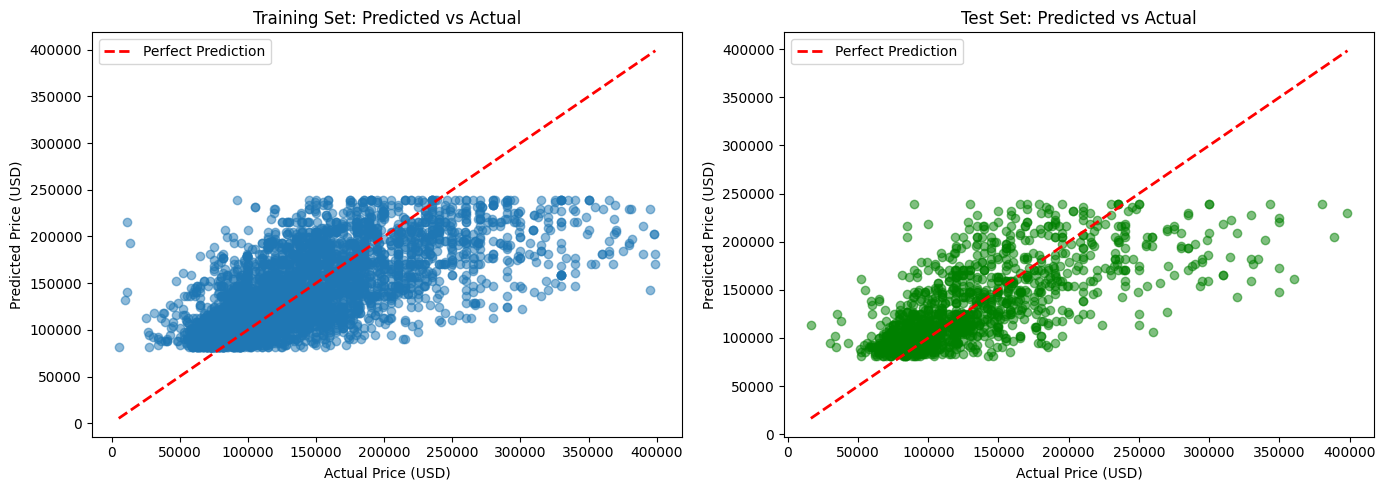

In [22]:
# Creating the plots:
fig, axes = plt.subplots(1,2, figsize=(14,5))

axes[0].scatter(y_train, y_pred_train, alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()],
             [y_train.min(), y_train.max()],
             'r--', lw=2, label='Perfect Prediction')

axes[0].set_title("Training Set: Predicted vs Actual")
axes[0].set_xlabel("Actual Price (USD)")
axes[0].set_ylabel("Predicted Price (USD)")
axes[0].legend()

axes[1].scatter(y_test, y_pred_test, alpha=0.5, color='green')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')

axes[1].set_title("Test Set: Predicted vs Actual")
axes[1].set_xlabel("Actual Price (USD)")
axes[1].set_ylabel("Predicted Price (USD)")
axes[1].legend()

plt.tight_layout()

**Residual Analysis**:

A **residual** is the difference between the actual value and the model's prediction:

$$e_i = y_i - \hat{y}_i$$

If the model predicted 280,000 but the actual price was $320,000, the residual is +40,000 (positive = underestimated). If it predicted 350,000 for a 300,000 apartment, the residual is -50,000 (negative = overestimated).



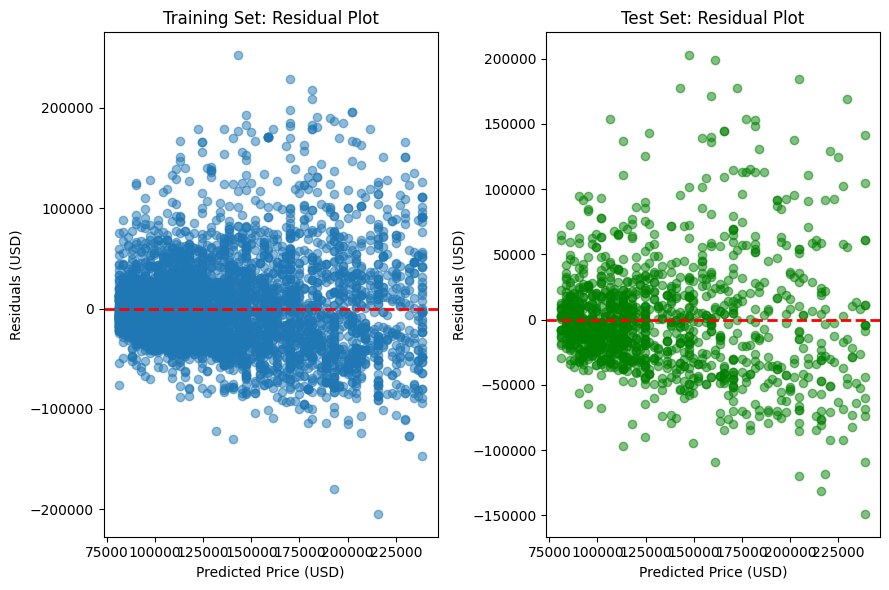

In [25]:
residual_train = y_train - y_pred_train
residual_test = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(9, 6))

# Training residuals
axes[0].scatter(y_pred_train, residual_train, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Price (USD)')
axes[0].set_ylabel('Residuals (USD)')
axes[0].set_title('Training Set: Residual Plot')

# Test residuals
axes[1].scatter(y_pred_test, residual_test, alpha=0.5, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price (USD)')
axes[1].set_ylabel('Residuals (USD)')
axes[1].set_title('Test Set: Residual Plot')

plt.tight_layout()

*Interpreting Residual Plots**
>
> **Good pattern:** Residuals randomly scattered around zero — no curve, no funnel, no systematic trend. This is what we are hoping to see.

> **Bad pattern — curved residuals:** The residuals form a curve (high for small and large predicted values, low in the middle, or vice versa). This indicates a **non-linear relationship** that a linear model cannot capture. Consider adding polynomial features or using a non-linear model.

> **Bad pattern — funnel shape (heteroscedasticity):** The spread of residuals increases as predicted values increase. For expensive apartments, the model's errors are much larger in absolute terms than for cheap apartments.

> **Bad pattern — systematic bias:** Residuals are consistently positive (model always underestimates) or consistently negative (model always overestimates). This suggests the model's functional form is wrong — it is not the right type of equation for this relationship.


5.4 Line of Best Fit

The final visualization places the model's predictions as a line over the original scatter plot — this is the "line of best fit" that linear regression has learned from the training data.

**What the line shows:** For every possible value of `surface_covered_in_m2`, the line shows the model's predicted price. The slope of the line is the coefficient $\beta_1$; the y-intercept is $\beta_0$.

**What to notice:** How well does the line thread through the cloud of points? Are there systematic deviations (e.g., does the line overestimate for very small apartments and underestimate for large ones)? A perfect linear fit would have all points balanced symmetrically around the line.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


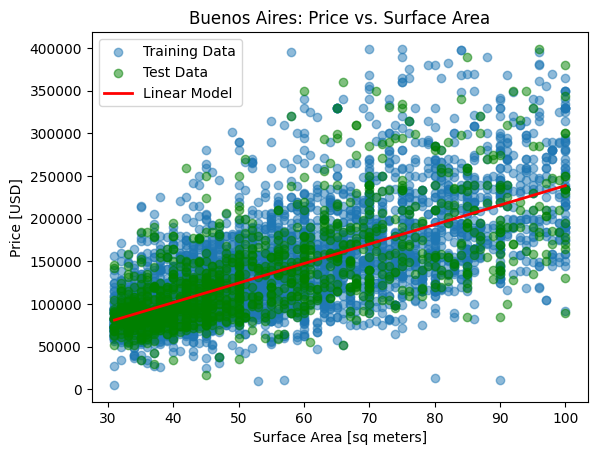

In [26]:
fig, ax = plt.subplots()
ax.scatter(X_train, y_train, alpha=0.5, label='Training Data')
ax.scatter(X_test, y_test, alpha=0.5, color='green', label='Test Data')

# Create evenly-spaced x values for the line
x_line = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)
ax.plot(x_line, model_lr.predict(x_line), color="red", linewidth=2, label="Linear Model")

ax.set_xlabel("Surface Area [sq meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Buenos Aires: Price vs. Surface Area")
ax.legend()